In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/final_accidents_weather_air_quality.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (74326, 37)


,Accident_Index,Longitude,Latitude,Accident_Severity,Date,Time,Day_of_Week,Number_of_Vehicles,Number_of_Casualties,Road_Type,...,temperature_2m,rain,snowfall,weather_code,cloud_cover,wind_speed_10m,pm2_5,pm10,nitrogen_dioxide,european_aqi
0,201301BS70003,-0.171402,51.486361,2,2013-01-02,09:08,4,2,1,6,...,4.4,0.0,0.0,3,100,11.9,7.5,17.5,44.9,22.0
1,201301BS70005,-0.173356,51.495115,3,2013-01-04,08:16,6,1,2,6,...,8.3,0.0,0.0,3,97,14.1,6.3,14.4,23.9,20.0
2,201301BS70006,-0.210767,51.518353,3,2013-01-07,11:45,2,1,1,6,...,7.3,0.0,0.0,3,100,11.8,14.5,19.6,45.4,28.0
3,201301BS70007,-0.209675,51.516808,3,2013-01-10,10:40,5,2,1,6,...,1.4,0.0,0.0,3,100,3.6,30.6,41.5,58.1,51.0
4,201301BS70009,-0.194332,51.492922,3,2013-01-04,17:47,6,2,1,2,...,9.0,0.0,0.0,3,89,11.2,10.8,17.7,41.9,21.0


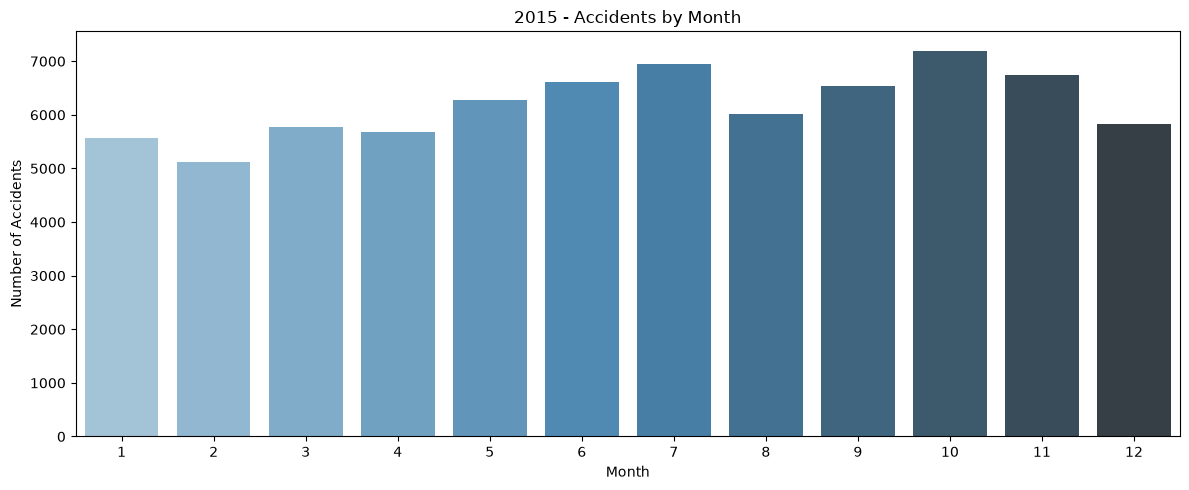

In [4]:
plt.figure(figsize=(12,5))
monthly = df.groupby('Month')['Longitude'].count()
sns.barplot(x=monthly.index, y=monthly.values, palette='Blues_d')
plt.title('2015 - Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()

In [3]:
print(df.columns.tolist())

['Accident_Index', 'Longitude', 'Latitude', 'Accident_Severity', 'Date', 'Time', 'Day_of_Week', 'Number_of_Vehicles', 'Number_of_Casualties', 'Road_Type', 'Speed_limit', 'Junction_Detail', 'Junction_Control', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'Year', 'Severity_Label', 'Severe_Accident', 'Accident_DateTime', 'Month', 'Hour', 'Weather_Hour', 'Grid_Latitude', 'Grid_Longitude', 'Police_Force', 'temperature_2m', 'rain', 'snowfall', 'weather_code', 'cloud_cover', 'wind_speed_10m', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'european_aqi']


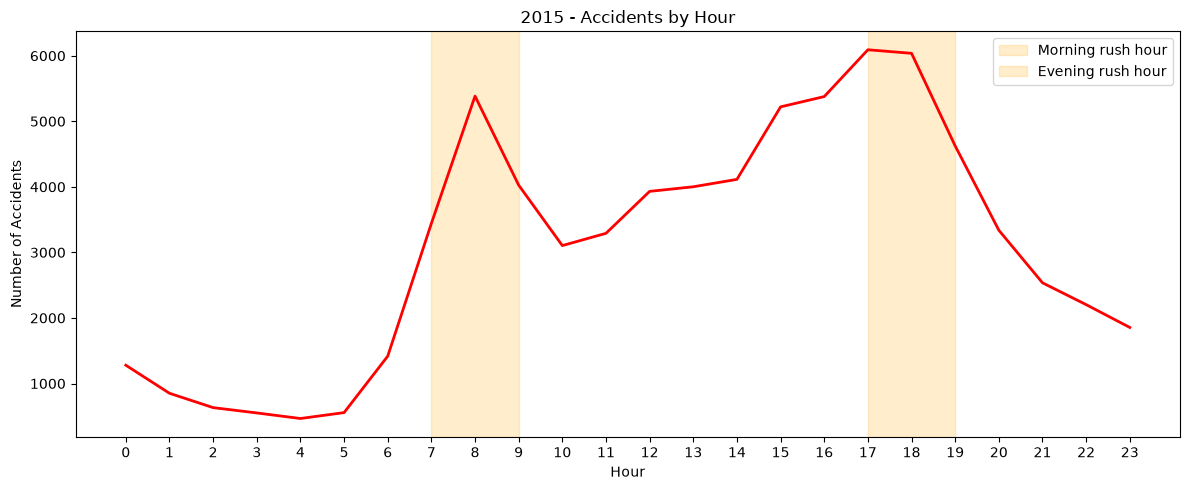

In [5]:
plt.figure(figsize=(12,5))
hourly = df.groupby('Hour')['Longitude'].count()
sns.lineplot(x=hourly.index, y=hourly.values, color='red', linewidth=2)
plt.title('2015 - Accidents by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.xticks(range(0,24))
plt.axvspan(7, 9, alpha=0.2, color='orange', label='Morning rush hour')
plt.axvspan(17, 19, alpha=0.2, color='orange', label='Evening rush hour')
plt.legend()
plt.tight_layout()
plt.show()

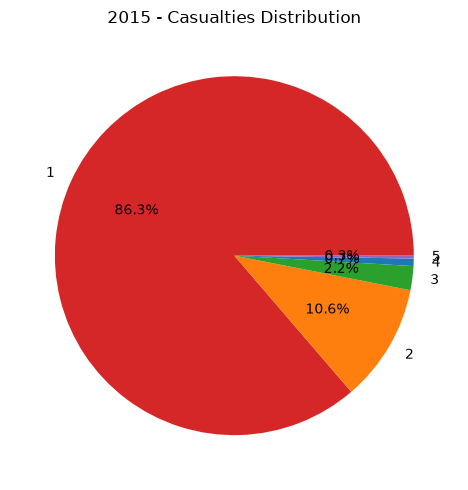

In [6]:
plt.figure(figsize=(7,5))
severity = df['Number_of_Casualties'].value_counts().head(5)
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
plt.pie(severity.values, labels=severity.index, autopct='%1.1f%%', colors=colors)
plt.title('2015 - Casualties Distribution')
plt.tight_layout()
plt.show()

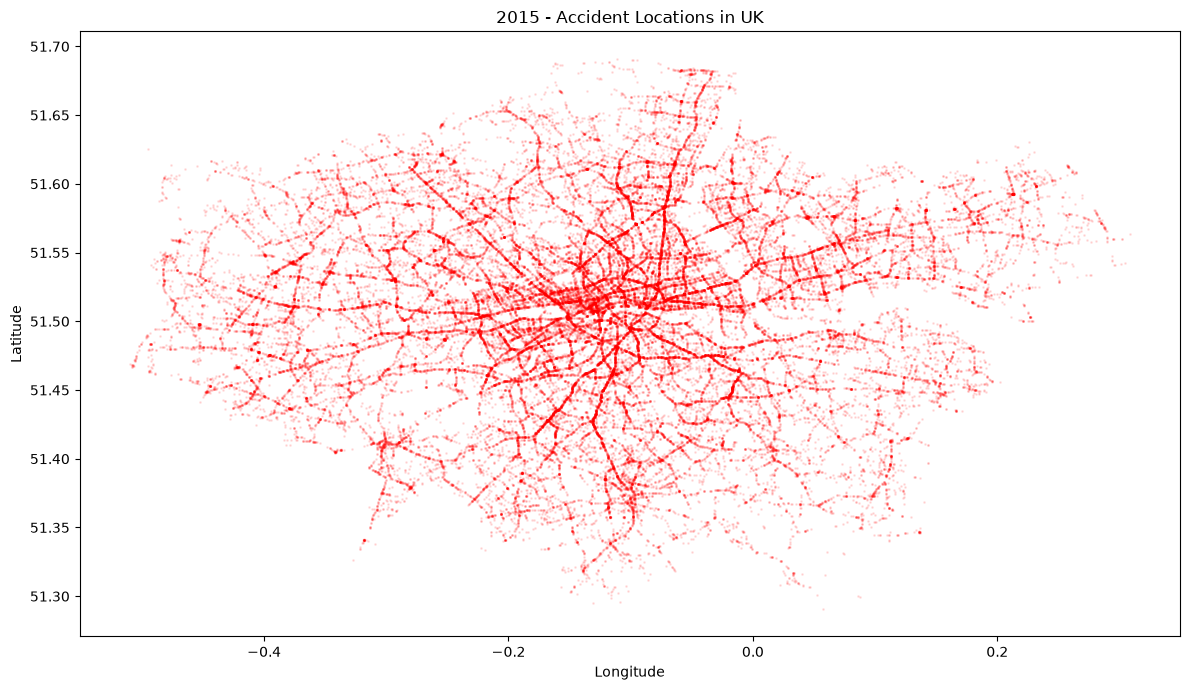

In [7]:
plt.figure(figsize=(12,7))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.1, s=1, c='red')
plt.title('2015 - Accident Locations in UK')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

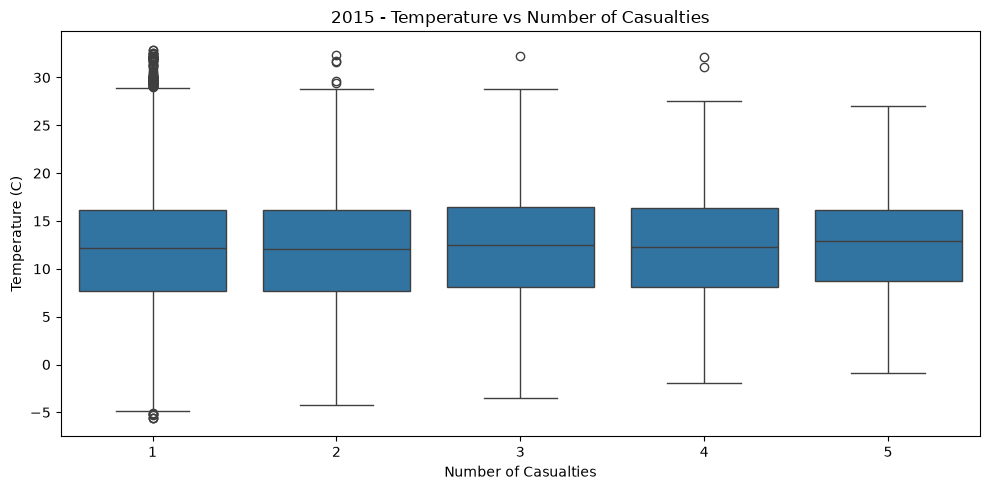

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Number_of_Casualties',
    y='temperature_2m',
    data=df[df['Number_of_Casualties'] <= 5]
)
plt.title('2015 - Temperature vs Number of Casualties')
plt.xlabel('Number of Casualties')
plt.ylabel('Temperature (C)')
plt.tight_layout()
plt.show()

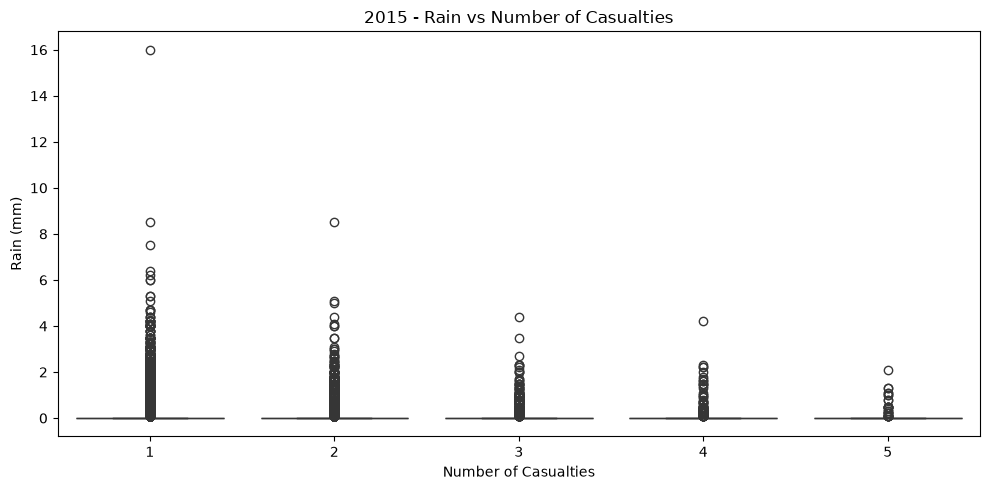

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Number_of_Casualties',
    y='rain',
    data=df[df['Number_of_Casualties'] <= 5],
    palette='Blues'
)
plt.title('2015 - Rain vs Number of Casualties')
plt.xlabel('Number of Casualties')
plt.ylabel('Rain (mm)')
plt.tight_layout()
plt.show()

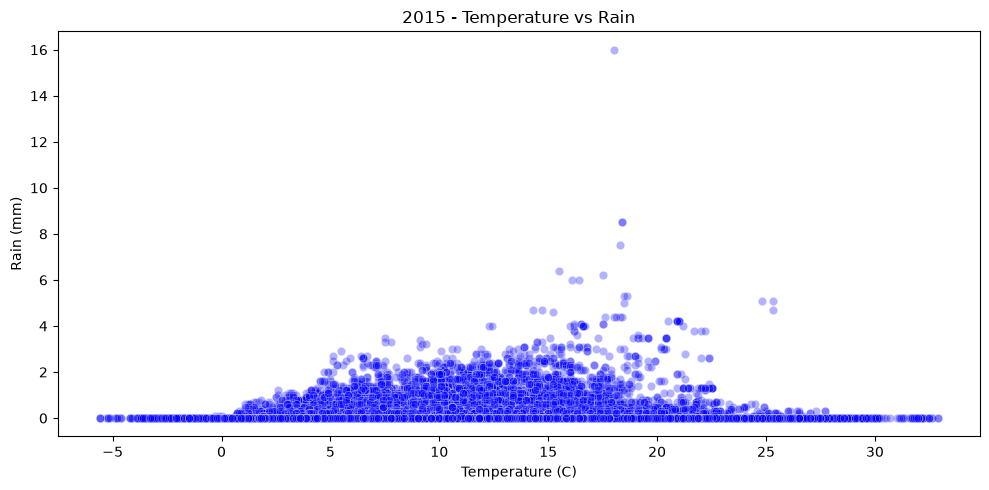

In [10]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='temperature_2m', y='rain', data=df, alpha=0.3, color='blue')
plt.title('2015 - Temperature vs Rain')
plt.xlabel('Temperature (C)')
plt.ylabel('Rain (mm)')
plt.tight_layout()
plt.show()

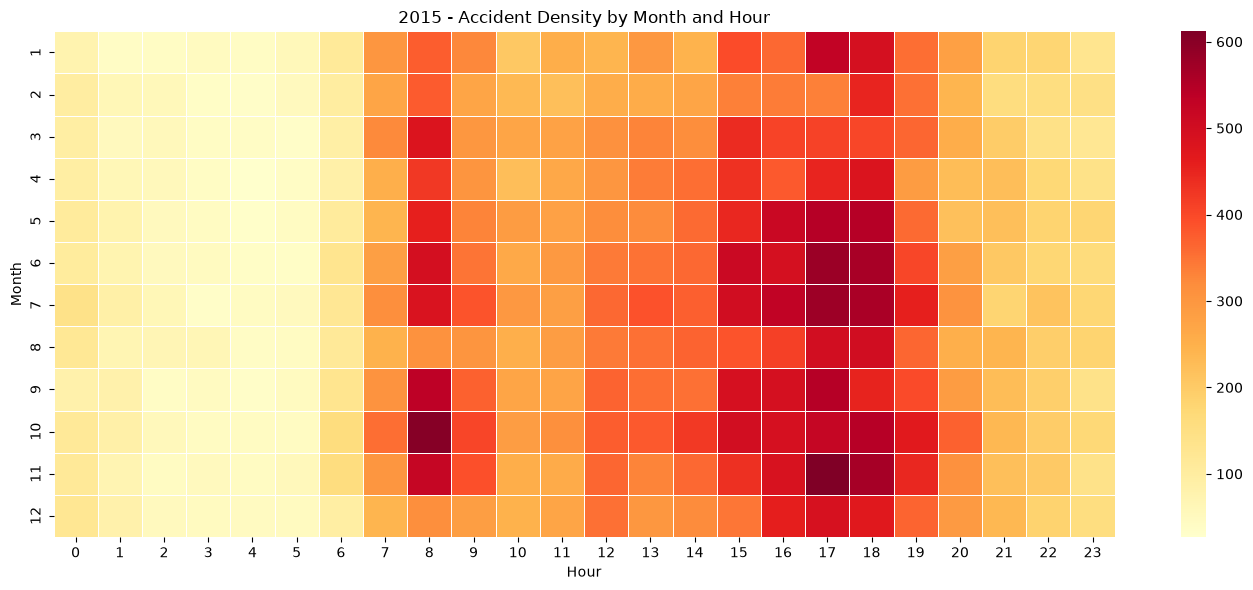

In [11]:
plt.figure(figsize=(14,6))
heatmap_data = df.groupby(['Month','Hour'])['Longitude'].count().unstack()
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('2015 - Accident Density by Month and Hour')
plt.xlabel('Hour')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

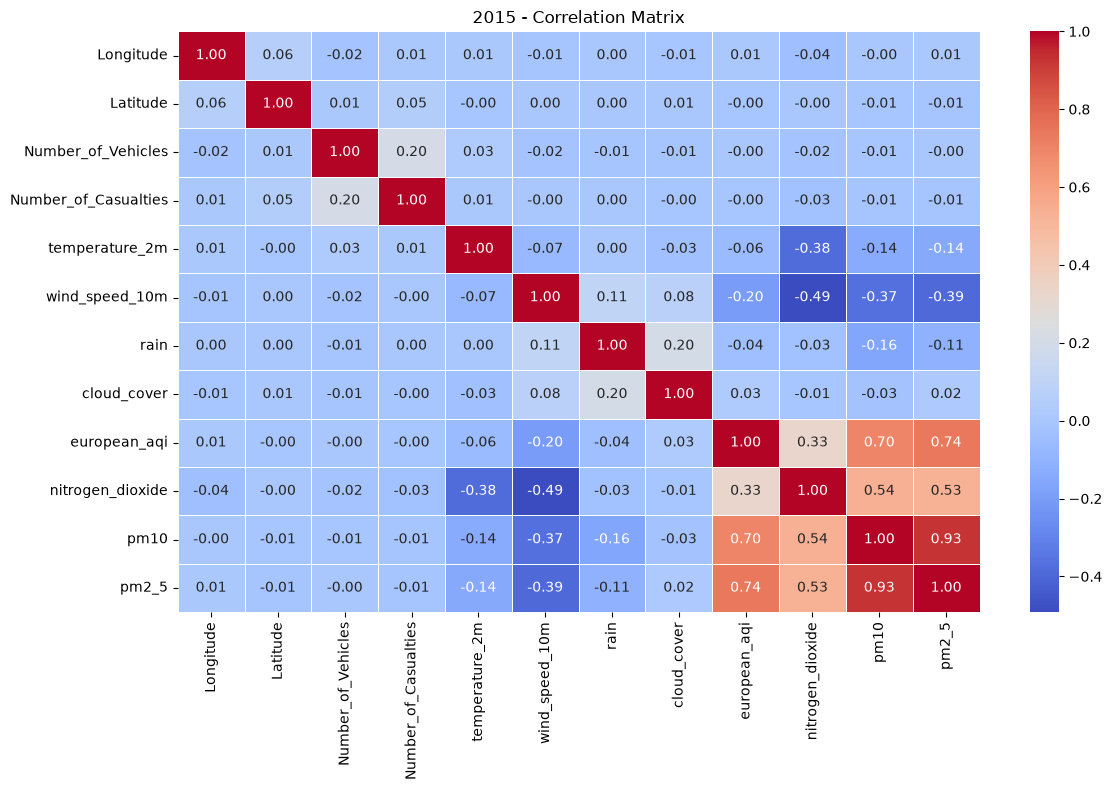

In [12]:
plt.figure(figsize=(12,8))
numeric_cols = ['Longitude','Latitude','Number_of_Vehicles','Number_of_Casualties',
                'temperature_2m','wind_speed_10m','rain','cloud_cover',
                'european_aqi','nitrogen_dioxide','pm10','pm2_5']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('2015 - Correlation Matrix')
plt.tight_layout()
plt.show()

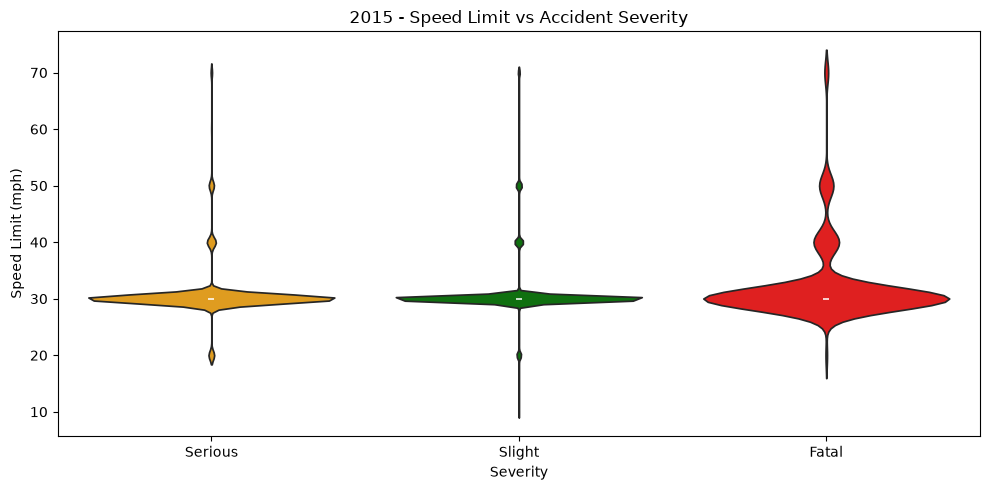

In [13]:

plt.figure(figsize=(10,5))
sns.violinplot(
    x='Severity_Label',
    y='Speed_limit',
    data=df,
    palette={'Fatal':'red', 'Serious':'orange', 'Slight':'green'}
)
plt.title('2015 - Speed Limit vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Speed Limit (mph)')
plt.tight_layout()
plt.show()

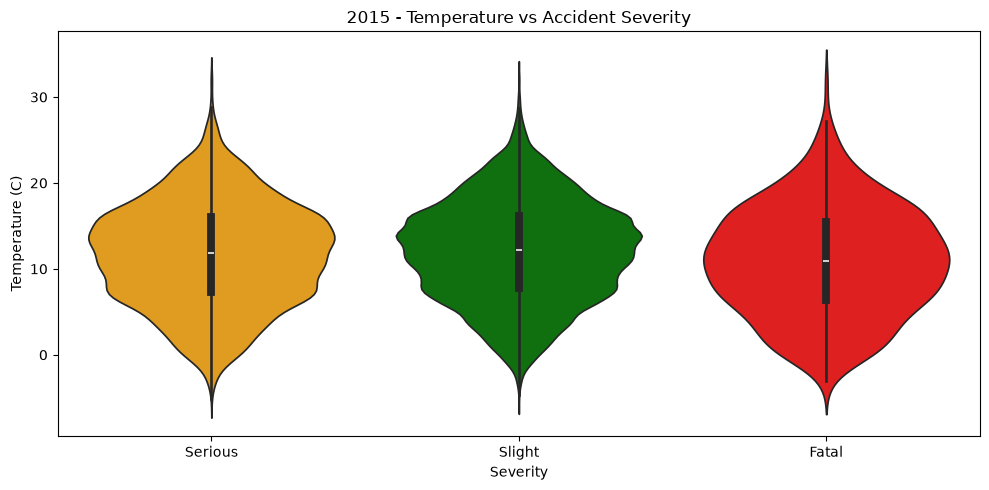

In [14]:

plt.figure(figsize=(10,5))
sns.violinplot(
    x='Severity_Label',
    y='temperature_2m',
    data=df,
    palette={'Fatal':'red', 'Serious':'orange', 'Slight':'green'}
)
plt.title('2015 - Temperature vs Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Temperature (C)')
plt.tight_layout()
plt.show()